# 2.5 自动微分 

In [1]:
import torch

我们可以在创建一个tensor的时候requires_grad=True，使得其有梯度

也可以x.requires_grad_(True)

In [2]:
x=torch.arange(4,requires_grad=True)
x.grad

RuntimeError: Only Tensors of floating point and complex dtype can require gradients

这个错误的意思是只有浮点数以及复数可以有梯度

In [3]:
x=torch.arange(4,dtype=torch.float32,requires_grad=True)
x.grad # 默认值是None

我们做个测试
$$
y=dot(x,x)=x^Tx=\sum_{i=1}^{n} x_i^2
$$
于是
$$
\frac{dy}{dx}=\frac{d\sum_{i=1}^{n} x_i^2}{dx}
=[\frac{d\sum_{i=1}^{n} x_i^2}{dx_1},\frac{d\sum_{i=1}^{n} x_i^2}{dx_2},\cdot,\frac{d\sum_{i=1}^{n} x_i^2}{dx_n}]
=2[x_1,x_2,\cdot,x_n]
$$



In [4]:
def f(x):
    return torch.dot(x,x)

In [5]:
y=f(x)
y

tensor(14., grad_fn=<DotBackward0>)

利用反向传播计算y对x的梯度

In [6]:
y.backward()
x.grad,2*x==x.grad

(tensor([0., 2., 4., 6.]), tensor([True, True, True, True]))

[**现在计算`x`的另一个函数。**]

In [7]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

## 分离计算

有时，我们希望[**将某些计算移动到记录的计算图之外**]。
例如，假设`y`是作为`x`的函数计算的，而`z`则是作为`y`和`x`的函数计算的。
想象一下，我们想计算`z`关于`x`的梯度，但由于某种原因，希望将`y`视为一个常数，
并且只考虑到`x`在`y`被计算后发挥的作用。

这里可以分离`y`来返回一个新变量`u`，该变量与`y`具有相同的值，
但丢弃计算图中如何计算`y`的任何信息。
换句话说，梯度不会向后流经`u`到`x`。
因此，下面的反向传播函数计算`z=u*x`关于`x`的偏导数，同时将`u`作为常数处理，
而不是`z=x*x*x`关于`x`的偏导数。

其实就是
f(x) =
\begin{cases} 
z=y*x,  \\
y=x*x, 
\end{cases}

然后另$u=y=x*x$为一个常量，$z=f(y,x)=f(x)$

注意，这个u只是不参与计算图的计算，不是不计算

In [8]:
x.grad.zero_()
y=x*x
u=y.detach()
z=u*x

In [9]:
z.backward()
x.grad,x.grad==u

RuntimeError: grad can be implicitly created only for scalar outputs

原因： 在 z.backward() 时，z 不是一个标量（scalar），而是一个张量（tensor）。PyTorch 的 backward() 默认只支持标量（单个值）进行自动求导。

 **解决方案**
**方法 1：提供 `gradient` 参数**
如果 `z` 是一个张量，你需要提供一个和 `z` 形状一致的 `gradient`，告诉 PyTorch 该如何计算梯度。例如：
```python
z.backward(torch.ones_like(z))
```
`torch.ones_like(z)` 生成一个和 `z` 形状相同的全 1 张量，作为梯度传入，这样 `backward()` 才能正常执行。

---

**方法 2：如果 `z` 需要转换为标量**
如果 `z` 本质上是一个标量，但由于形状问题不能直接 `backward()`，可以用 `.sum()` 先转换：
```python
z.sum().backward()
```
这样 `z.sum()` 变成一个标量，就可以正常求导了。

---

**总结**
- **如果 `z` 是标量**，可以直接 `z.backward()`。
- **如果 `z` 是张量**：
  - 方案 1：提供 `gradient` 参数 `z.backward(torch.ones_like(z))`。
  - 方案 2：先 `.sum()` 再 `backward()`，即 `z.sum().backward()`。


In [10]:
x.grad.zero_()
z.sum().backward()
x.grad,x.grad==u

(tensor([0., 1., 4., 9.]), tensor([True, True, True, True]))

注意，这个u只是不参与计算图的计算，不是不计算

**`detach()` 只是切断计算图的连接，并不会影响 `u` 的数值计算**。  

---

**更详细的解析**
你原来的计算图是：
1. $y = x \times x$
2. $z = y \times x$

如果我们直接求导：
$$
    \frac{\partial z}{\partial x} = \frac{\partial (y \cdot x)}{\partial x} = \frac{\partial (x^2 \cdot x)}{\partial x} = 3x^2
$$
但是如果 **将 `y` 视为一个常数（`detach()` 处理）**，那就是：
- **视 `y` 为一个独立的常数**，也就是 $u = y = x \times x$ **不会再对 `x` 进行反向传播**，那么：
$$
    \frac{\partial z}{\partial x} = \frac{\partial (u \cdot x)}{\partial x} = u
$$
也就是 $x^2$，而不是 $3x^2$。

**总结**
- **`detach()` 让 `y` 变成一个 " 常数 "**，不参与 `x` 的梯度传播。
- **影响的是梯度传播，不影响数值计算**。
- **在 `z.backward()` 计算梯度时，`y` 作为常数，梯度计算和 `y` 无关**。

这种方式在 **某些需要手动控制梯度计算** 的深度学习任务中很有用，比如 **对某些层不进行梯度更新（冻结参数）** 或 **手动修改计算图**。🚀



 使$f(x)=\sin(x)$，绘制$f(x)$和$\frac{df(x)}{dx}$的图像，其中后者不使用$f'(x)=\cos(x)$。

In [11]:
x=torch.arange(-5,5,0.1,dtype=torch.float32,requires_grad=True)
y=torch.sin(x)

y.backward(torch.ones_like(y))
x.grad

tensor([ 0.2837,  0.1865,  0.0875, -0.0124, -0.1122, -0.2108, -0.3073, -0.4008,
        -0.4903, -0.5748, -0.6536, -0.7259, -0.7910, -0.8481, -0.8968, -0.9365,
        -0.9668, -0.9875, -0.9983, -0.9991, -0.9900, -0.9710, -0.9422, -0.9041,
        -0.8569, -0.8011, -0.7374, -0.6663, -0.5885, -0.5048, -0.4161, -0.3233,
        -0.2272, -0.1288, -0.0292,  0.0707,  0.1700,  0.2675,  0.3624,  0.4536,
         0.5403,  0.6216,  0.6967,  0.7648,  0.8253,  0.8776,  0.9211,  0.9553,
         0.9801,  0.9950,  1.0000,  0.9950,  0.9801,  0.9553,  0.9211,  0.8776,
         0.8253,  0.7648,  0.6967,  0.6216,  0.5403,  0.4536,  0.3624,  0.2675,
         0.1700,  0.0707, -0.0292, -0.1288, -0.2272, -0.3233, -0.4161, -0.5048,
        -0.5885, -0.6663, -0.7374, -0.8011, -0.8569, -0.9041, -0.9422, -0.9710,
        -0.9900, -0.9991, -0.9983, -0.9875, -0.9668, -0.9365, -0.8968, -0.8481,
        -0.7910, -0.7259, -0.6536, -0.5748, -0.4903, -0.4008, -0.3073, -0.2108,
        -0.1122, -0.0124,  0.0875,  0.18

In [12]:
import matplotlib.pyplot as plt

这里要注意要detach

不然报错：

RuntimeError                              Traceback (most recent call last)
d:\VScode_workspace\d2l-zh\test_gyk\chapter2\2.5 autograd.ipynb 单元格 26 line 1
----> 1 plt.plot(x.numpy(),x.grad.detach().numpy())
      2 plt.show()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

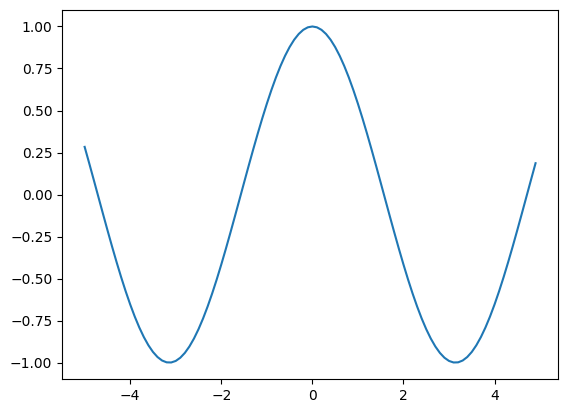

In [16]:
plt.plot(x.detach().numpy(),x.grad.detach().numpy())
plt.show()